# PySR Symbolic Regression -- Hyperparameter Sweep & SINDy Comparison

**2 Algorithms**: Standard PySR, Hybrid PySR (pooled runs)

**Sweep axes**: parsimony x maxsize x library (No-lam / With-lam)

**3 Metrics**: MSE, ATE (A/B/C/D/F), R-squared

**3 Regimes**: Bouncing, Rolling, Flight | **3 DOFs**: a_x, a_y, a_theta

| Sweep param | Values | Purpose |
|---|---|---|
| parsimony | 0.001, 0.01, 0.1 | Complexity penalty (like SINDy threshold) |
| maxsize | 15, 25 | Expression cap (like SINDy library size) |
| library | No-lam, With-lam | Feature set (+/- contact forces) |

**Total fits**: 3 x 2 x 2 x 2 x 3 x 3 = 216 → **108 rows per algorithm** (~36 min max, 10 s/fit)

ATE grading: A < 0.01, B < 0.05, C < 0.15, D < 0.50, F >= 0.50


In [16]:
import sys, os, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error
from IPython.display import display, HTML
warnings.filterwarnings('ignore')

PROJ = r'C:\Users\braid\OneDrive\Desktop\Data Driven Modeling Project'
sys.path.insert(0, PROJ)

from pipeline.data_loader import load_all
from pipeline.preprocessing import regime_aware_split, temporal_split_frac
from pysr import PySRRegressor

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 1e-20 else 0.0

def compute_open_loop_ate(y_pred_seg, q_true_seg, u_true_seg, dt):
    n = len(y_pred_seg)
    if n < 2:
        return 0.0
    q_sim = np.zeros(n)
    u_sim = np.zeros(n)
    q_sim[0] = q_true_seg[0]
    u_sim[0] = u_true_seg[0]
    for i in range(n - 1):
        u_sim[i + 1] = u_sim[i] + y_pred_seg[i] * dt
        q_sim[i + 1] = q_sim[i] + u_sim[i + 1] * dt
    return float(np.sqrt(np.mean((q_true_seg - q_sim) ** 2)))

def ate_grade(ate):
    if not np.isfinite(ate): return 'F'
    if ate < 0.01: return 'A'
    if ate < 0.05: return 'B'
    if ate < 0.15: return 'C'
    if ate < 0.50: return 'D'
    return 'F'

def safe_predict(model, X):
    y = model.predict(X)
    mask = ~np.isfinite(y)
    if mask.any():
        y[mask] = np.nanmean(y[~mask]) if (~mask).any() else 0.0
    return y

DOF_LABELS = ['a_x', 'a_y', 'a_theta']
REGIMES = ['bouncing', 'rolling', 'flight']

print('Imports loaded.')

Imports loaded.


## S1 Data Loading & Splits

In [17]:
all_runs = load_all()

for regime, runs in all_runs.items():
    print(f'{regime.upper()} ({len(runs)} runs):')
    for r in runs:
        print(f'  {r.name}: N={r.N}, dt={r.dt:.6f}')

# Standard PySR: first run, temporal 60/20/20  (mirrors Standard SINDy)
regime_data = {}
print('\n--- Standard PySR splits (first run, temporal 60/20/20) ---')
for regime in REGIMES:
    run = all_runs[regime][0]
    sp = temporal_split_frac(run.N, 0.60, 0.20)
    regime_data[regime] = {'run': run, 'split': sp}
    print(f'  {regime}: train={len(sp.idx_train)} val={len(sp.idx_val)} test={len(sp.idx_test)}')

# Hybrid PySR: pool all runs, regime-aware 60/20/20  (mirrors Hybrid SINDy)
pooled_data = {}
print('\n--- Hybrid PySR splits (pooled runs, regime-aware 60/20/20) ---')
for regime in REGIMES:
    runs = all_runs[regime]
    q_all = np.vstack([r.q for r in runs])
    u_all = np.vstack([r.u for r in runs])
    qddot_all = np.vstack([r.qddot for r in runs])
    lN_all = np.concatenate([r.lambda_N for r in runs])
    lF_all = np.concatenate([r.lambda_F for r in runs])
    dt = runs[0].dt
    N_pool = len(lN_all)
    sp = regime_aware_split(N_pool, lN_all)
    pooled_data[regime] = {
        'q': q_all, 'u': u_all, 'qddot': qddot_all,
        'lambda_N': lN_all, 'lambda_F': lF_all,
        'dt': dt, 'split': sp, 'N': N_pool,
    }
    print(f'  {regime}: N={N_pool} train={len(sp.idx_train)} val={len(sp.idx_val)} test={len(sp.idx_test)}')

print('\nData ready.')

BOUNCING (3 runs):
  bouncing_ball_1: N=1000, dt=0.006264
  bouncing_ball_2: N=1000, dt=0.006264
  bouncing_ball_3: N=1000, dt=0.006264
ROLLING (2 runs):
  rolling_1: N=1000, dt=0.006264
  rolling_2: N=1000, dt=0.006264
FLIGHT (2 runs):
  flight_1: N=1000, dt=0.006264
  flight_2: N=1000, dt=0.006264

--- Standard PySR splits (first run, temporal 60/20/20) ---
  bouncing: train=600 val=200 test=200
  rolling: train=600 val=200 test=200
  flight: train=600 val=200 test=200

--- Hybrid PySR splits (pooled runs, regime-aware 60/20/20) ---
  bouncing: N=3000 train=1799 val=599 test=602
  rolling: N=2000 train=1215 val=392 test=393
  flight: N=2000 train=1199 val=399 test=402

Data ready.


## S2 Sweep Configuration

| Axis | Values | Count |
|---|---|---|
| parsimony | 0.001, 0.01, 0.1 | 3 |
| maxsize | 15, 25 | 2 |
| library | No-lam (8 feat), With-lam (10 feat) | 2 |
| algorithm | PySR (single run, **temporal** split), Hybrid PySR (pooled, **regime-aware** split) | 2 |
| regime | bouncing, rolling, flight | 3 |
| DOF | a_x, a_y, a_theta | 3 |

Total fits: 3 × 2 × 2 × 2 × 3 × 3 = **216 fits** (~36 min max, 10 s hard cap each)

→ **108 rows per algorithm** (6× more than before), covering the most informative axes.

Split mirrors SINDy pipeline: Standard → temporal, Hybrid → regime-aware


In [18]:
ACCEL_NAMES = ['xddot', 'yddot', 'thetaddot']

def _feat_names(target_dof, with_lambda=False):
    base = ['x', 'y', 'theta', 'xdot', 'ydot', 'thetadot']
    other = [ACCEL_NAMES[j] for j in range(3) if j != target_dof]
    names = base + other
    if with_lambda:
        names += ['lambda_N', 'lambda_F']
    return names

def build_features(q, u, qddot, target_dof,
                   lambda_N=None, lambda_F=None, with_lambda=False):
    other_idx = [j for j in range(3) if j != target_dof]
    X = np.hstack([q, u, qddot[:, other_idx]])
    if with_lambda:
        X = np.hstack([X, lambda_N.reshape(-1, 1), lambda_F.reshape(-1, 1)])
    return X

# ── Sweep: 3 parsimony × 2 maxsize → 216 fits (~36 min max) ──────────────────
# parsimony is the primary axis (analogous to SINDy threshold); maxsize is secondary.
# TIMEOUT_S=10 keeps total time feasible while still allowing meaningful search.
PARSIMONY_VALUES = [0.001, 0.01, 0.1]   # low → high complexity penalty
MAXSIZE_VALUES   = [15, 25]              # small / medium expression cap
LIB_VARIANTS     = [('No-lam', False), ('With-lam', True)]
ALGO_VARIANTS    = [('PySR', regime_data), ('Hybrid PySR', pooled_data)]
NITER      = 40               # high, but hard-capped by timeout below
NPOP       = 8
POP_SIZE   = 20
TIMEOUT_S  = 10               # hard cap: each fit stops after 10 seconds

n_fits = (len(PARSIMONY_VALUES) * len(MAXSIZE_VALUES) * len(LIB_VARIANTS)
          * len(ALGO_VARIANTS) * len(REGIMES) * len(DOF_LABELS))
print(f'Sweep: {len(PARSIMONY_VALUES)} parsimony x {len(MAXSIZE_VALUES)} maxsize'
      f' x {len(LIB_VARIANTS)} lib x {len(ALGO_VARIANTS)} algo'
      f' x {len(REGIMES)} regime x {len(DOF_LABELS)} DOF = {n_fits} fits')
print(f'Fixed: niterations={NITER}, populations={NPOP}, population_size={POP_SIZE}, timeout={TIMEOUT_S}s/fit')
print(f'Max time: {n_fits * TIMEOUT_S / 60:.0f} min  (hard cap per fit = {TIMEOUT_S}s)')


Sweep: 3 parsimony x 2 maxsize x 2 lib x 2 algo x 3 regime x 3 DOF = 216 fits
Fixed: niterations=40, populations=8, population_size=20, timeout=10s/fit
Max time: 36 min  (hard cap per fit = 10s)


## S3 Full PySR Sweep

Unified loop over all hyperparameter combinations.

In [19]:
all_rows = []
all_models = {}
t0_global = time.time()
fit_i = 0

for pars in PARSIMONY_VALUES:
    for mxsz in MAXSIZE_VALUES:
        for lib_label, with_lam in LIB_VARIANTS:

            for algo_name, data_source in ALGO_VARIANTS:
                for regime in REGIMES:
                    if algo_name == 'PySR':
                        run = data_source[regime]['run']
                        sp  = data_source[regime]['split']
                        q, u = run.q, run.u
                        lN, lF = run.lambda_N, run.lambda_F
                        qddot = run.qddot
                        dt = run.dt
                    else:
                        pdata = data_source[regime]
                        sp = pdata['split']
                        q, u = pdata['q'], pdata['u']
                        lN, lF = pdata['lambda_N'], pdata['lambda_F']
                        qddot = pdata['qddot']
                        dt = pdata['dt']

                    for d, dof in enumerate(DOF_LABELS):
                        feat_names = _feat_names(d, with_lam)
                        X = build_features(q, u, qddot, d, lN, lF, with_lam)
                        X_tr  = X[sp.idx_train]
                        X_val = X[sp.idx_val]
                        X_te  = X[sp.idx_test]
                        fit_i += 1
                        y = qddot[:, d]
                        y_tr  = y[sp.idx_train]
                        y_val = y[sp.idx_val]
                        y_te  = y[sp.idx_test]

                        tag = f'p={pars} ms={mxsz}'
                        print(f'[{fit_i}/{n_fits}] {algo_name:11s} | {regime:8s} | {lib_label:8s} | {tag} | {dof}',
                              end=' ', flush=True)
                        t1 = time.time()

                        model = PySRRegressor(
                            niterations=NITER,
                            populations=NPOP,
                            population_size=POP_SIZE,
                            timeout_in_seconds=TIMEOUT_S,   # ← hard cap per fit
                            binary_operators=['+', '-', '*', '/'],
                            unary_operators=['sin', 'cos', 'square'],
                            maxsize=mxsz,
                            parsimony=pars,
                            batching=True,
                            batch_size=256,
                            verbosity=0,
                        )
                        model.fit(X_tr, y_tr, variable_names=feat_names)

                        yp_tr  = safe_predict(model, X_tr)
                        yp_val = safe_predict(model, X_val)
                        yp_te  = safe_predict(model, X_te)
                        yp_all = safe_predict(model, X)

                        mse_tr  = float(mean_squared_error(y_tr, yp_tr))
                        mse_val = float(mean_squared_error(y_val, yp_val))
                        mse_te  = float(mean_squared_error(y_te, yp_te))
                        r2_val  = compute_r2(y_val, yp_val)
                        r2_te   = compute_r2(y_te, yp_te)
                        ate_v   = compute_open_loop_ate(
                            yp_all[sp.idx_val], q[sp.idx_val, d],
                            u[sp.idx_val, d], dt)

                        eq_str = str(model.sympy())
                        try:
                            cplx = int(model.get_best()['complexity'])
                        except Exception:
                            cplx = -1

                        key = (algo_name, regime, lib_label, pars, mxsz, dof)
                        all_models[key] = model

                        all_rows.append({
                            'algorithm': algo_name, 'regime': regime,
                            'library': lib_label, 'parsimony': pars,
                            'maxsize': mxsz, 'dof': dof,
                            'n_terms': cplx,
                            'MSE_train': mse_tr, 'MSE_val': mse_val,
                            'MSE_test': mse_te,
                            'R2_val': r2_val, 'R2_test': r2_te,
                            'ATE': ate_v, 'ate_grade': ate_grade(ate_v),
                            'equation': eq_str,
                        })
                        elapsed = time.time() - t1
                        print(f'R2={r2_val:.3f} ATE={ate_v:.4f}({ate_grade(ate_v)}) {elapsed:.0f}s')

df_pysr = pd.DataFrame(all_rows)
total_min = (time.time() - t0_global) / 60
print(f'\nSweep complete: {len(df_pysr)} rows in {total_min:.1f} min')
print(f'Grade dist:\n{df_pysr["ate_grade"].value_counts().sort_index().to_string()}')


[1/216] PySR        | bouncing | No-lam   | p=0.001 ms=15 | a_x R2=-2.210 ATE=0.0336(B) 2s
[2/216] PySR        | bouncing | No-lam   | p=0.001 ms=15 | a_y R2=0.000 ATE=0.2000(D) 1s
[3/216] PySR        | bouncing | No-lam   | p=0.001 ms=15 | a_theta R2=1.000 ATE=0.0032(A) 1s
[4/216] PySR        | rolling  | No-lam   | p=0.001 ms=15 | a_x R2=0.995 ATE=0.0012(A) 1s
[5/216] PySR        | rolling  | No-lam   | p=0.001 ms=15 | a_y R2=0.000 ATE=0.0000(A) 1s
[6/216] PySR        | rolling  | No-lam   | p=0.001 ms=15 | a_theta R2=0.995 ATE=0.0399(B) 1s
[7/216] PySR        | flight   | No-lam   | p=0.001 ms=15 | a_x R2=0.764 ATE=0.0536(C) 1s
[8/216] PySR        | flight   | No-lam   | p=0.001 ms=15 | a_y R2=-258.008 ATE=0.4399(D) 1s
[9/216] PySR        | flight   | No-lam   | p=0.001 ms=15 | a_theta R2=0.855 ATE=0.1604(D) 1s
[10/216] Hybrid PySR | bouncing | No-lam   | p=0.001 ms=15 | a_x R2=-1.408 ATE=0.6409(F) 1s
[11/216] Hybrid PySR | bouncing | No-lam   | p=0.001 ms=15 | a_y R2=-0.230 ATE=3.2

## S4 Save Results

In [20]:
csv_path = os.path.join(PROJ, 'pysr_sweep_results.csv')
df_pysr.to_csv(csv_path, index=False)
print(f'Saved {len(df_pysr)} rows to {csv_path}')

print('\n=== Mean metrics by algorithm ===')
print(df_pysr.groupby('algorithm')[['MSE_val','R2_val','ATE']].mean().to_string())

print('\n=== Mean metrics by parsimony ===')
print(df_pysr.groupby('parsimony')[['MSE_val','R2_val','ATE']].mean().to_string())

print('\n=== Mean metrics by maxsize ===')
print(df_pysr.groupby('maxsize')[['MSE_val','R2_val','ATE']].mean().to_string())

print('\n=== ATE grade distribution ===')
grade_ct = pd.crosstab(df_pysr['algorithm'], df_pysr['ate_grade'])
for g in ['A','B','C','D','F']:
    if g not in grade_ct.columns: grade_ct[g] = 0
print(grade_ct[['A','B','C','D','F']].to_string())

Saved 216 rows to C:\Users\braid\OneDrive\Desktop\Data Driven Modeling Project\pysr_sweep_results.csv

=== Mean metrics by algorithm ===
              MSE_val     R2_val       ATE
algorithm                                 
Hybrid PySR  0.353540   0.612529  2.136947
PySR         0.338169 -18.175206  0.067502

=== Mean metrics by parsimony ===
            MSE_val     R2_val       ATE
parsimony                               
0.001      0.204889  -6.184189  1.086823
0.010      0.408467  -9.584678  1.117998
0.100      0.424207 -10.575148  1.101853

=== Mean metrics by maxsize ===
          MSE_val     R2_val       ATE
maxsize                               
15       0.381910 -11.320797  1.099738
25       0.309799  -6.241879  1.104711

=== ATE grade distribution ===
ate_grade     A   B   C   D   F
algorithm                      
Hybrid PySR  13  11  10   2  72
PySR         34  39  19  16   0


## S5 Hyperparameter Analysis

Which parsimony x maxsize combination works best?

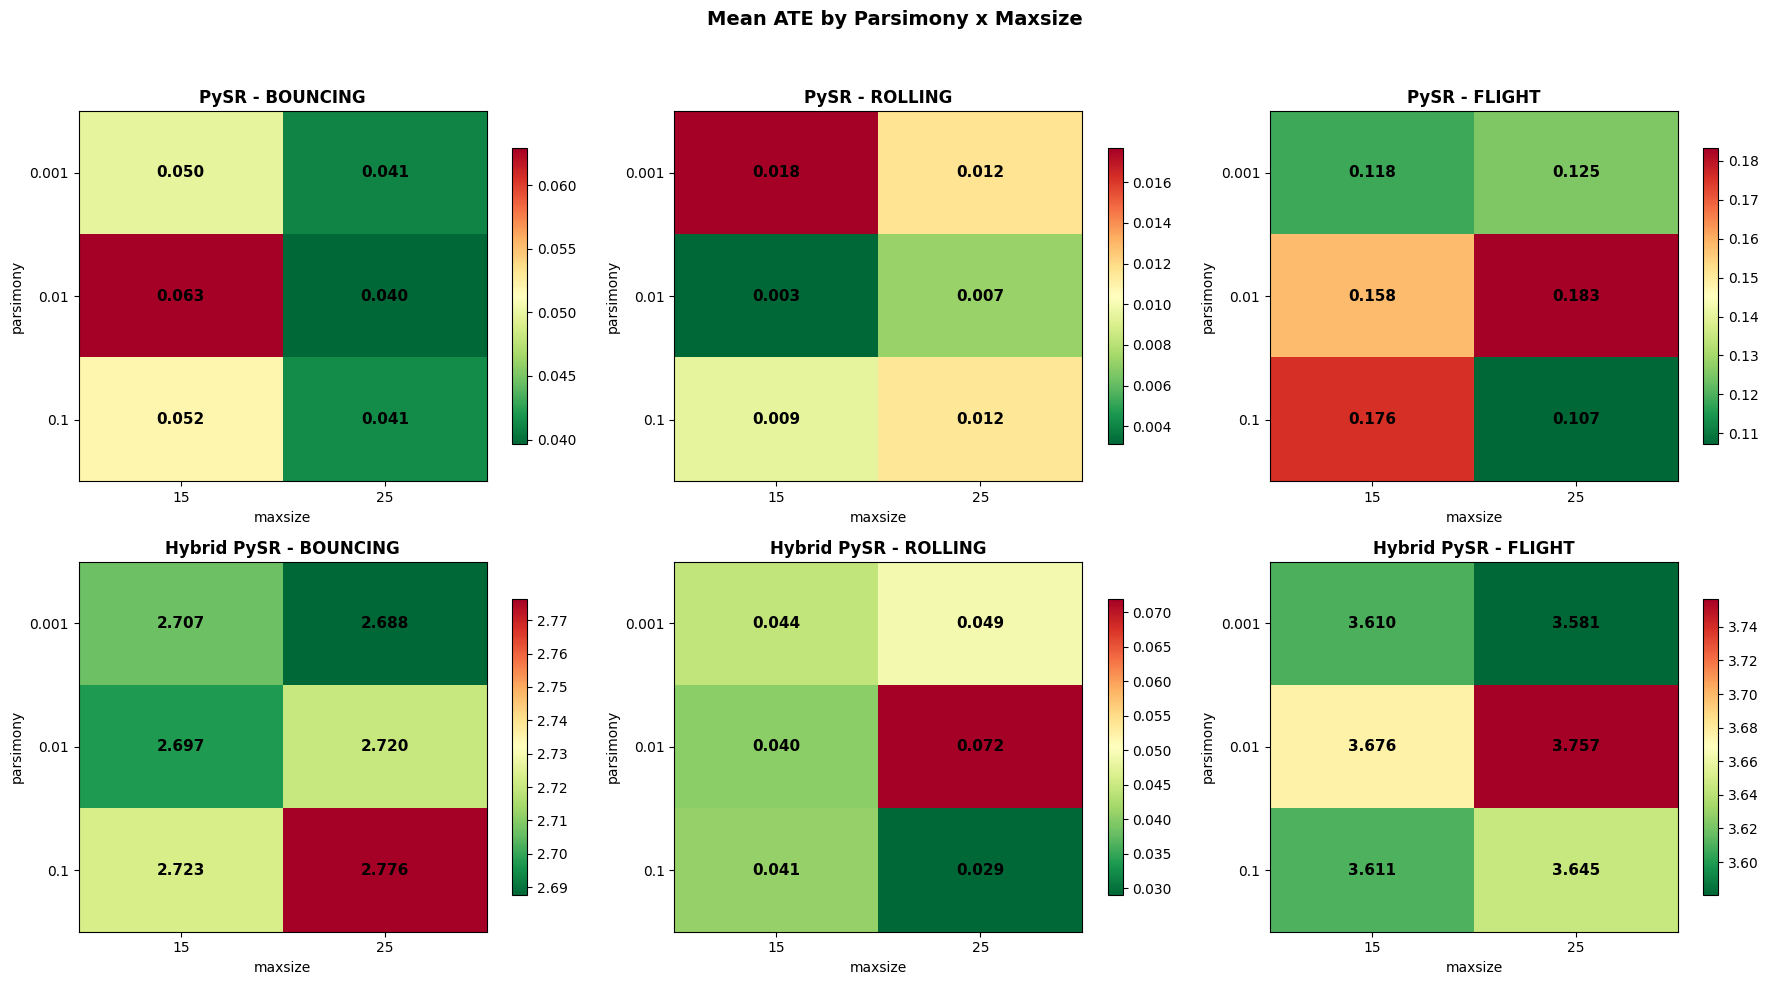

Hyperparameter heatmap saved.


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Mean ATE by Parsimony x Maxsize', fontsize=14, fontweight='bold')

for col, regime in enumerate(REGIMES):
    for row, algo in enumerate(['PySR', 'Hybrid PySR']):
        ax = axes[row, col]
        sub = df_pysr[(df_pysr['algorithm'] == algo) & (df_pysr['regime'] == regime)]
        piv = sub.pivot_table(index='parsimony', columns='maxsize',
                              values='ATE', aggfunc='mean')
        im = ax.imshow(piv.values, cmap='RdYlGn_r', aspect='auto')
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f'{v}' for v in piv.index])
        ax.set_xlabel('maxsize')
        ax.set_ylabel('parsimony')
        ax.set_title(f'{algo} - {regime.upper()}', fontweight='bold')
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                v = piv.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                            fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(PROJ, 'pysr_hyperparam_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Hyperparameter heatmap saved.')

## S6 Internal Comparison -- PySR vs Hybrid PySR

Best config per (algorithm x library x regime x DOF), compared on MSE / R2 / ATE.

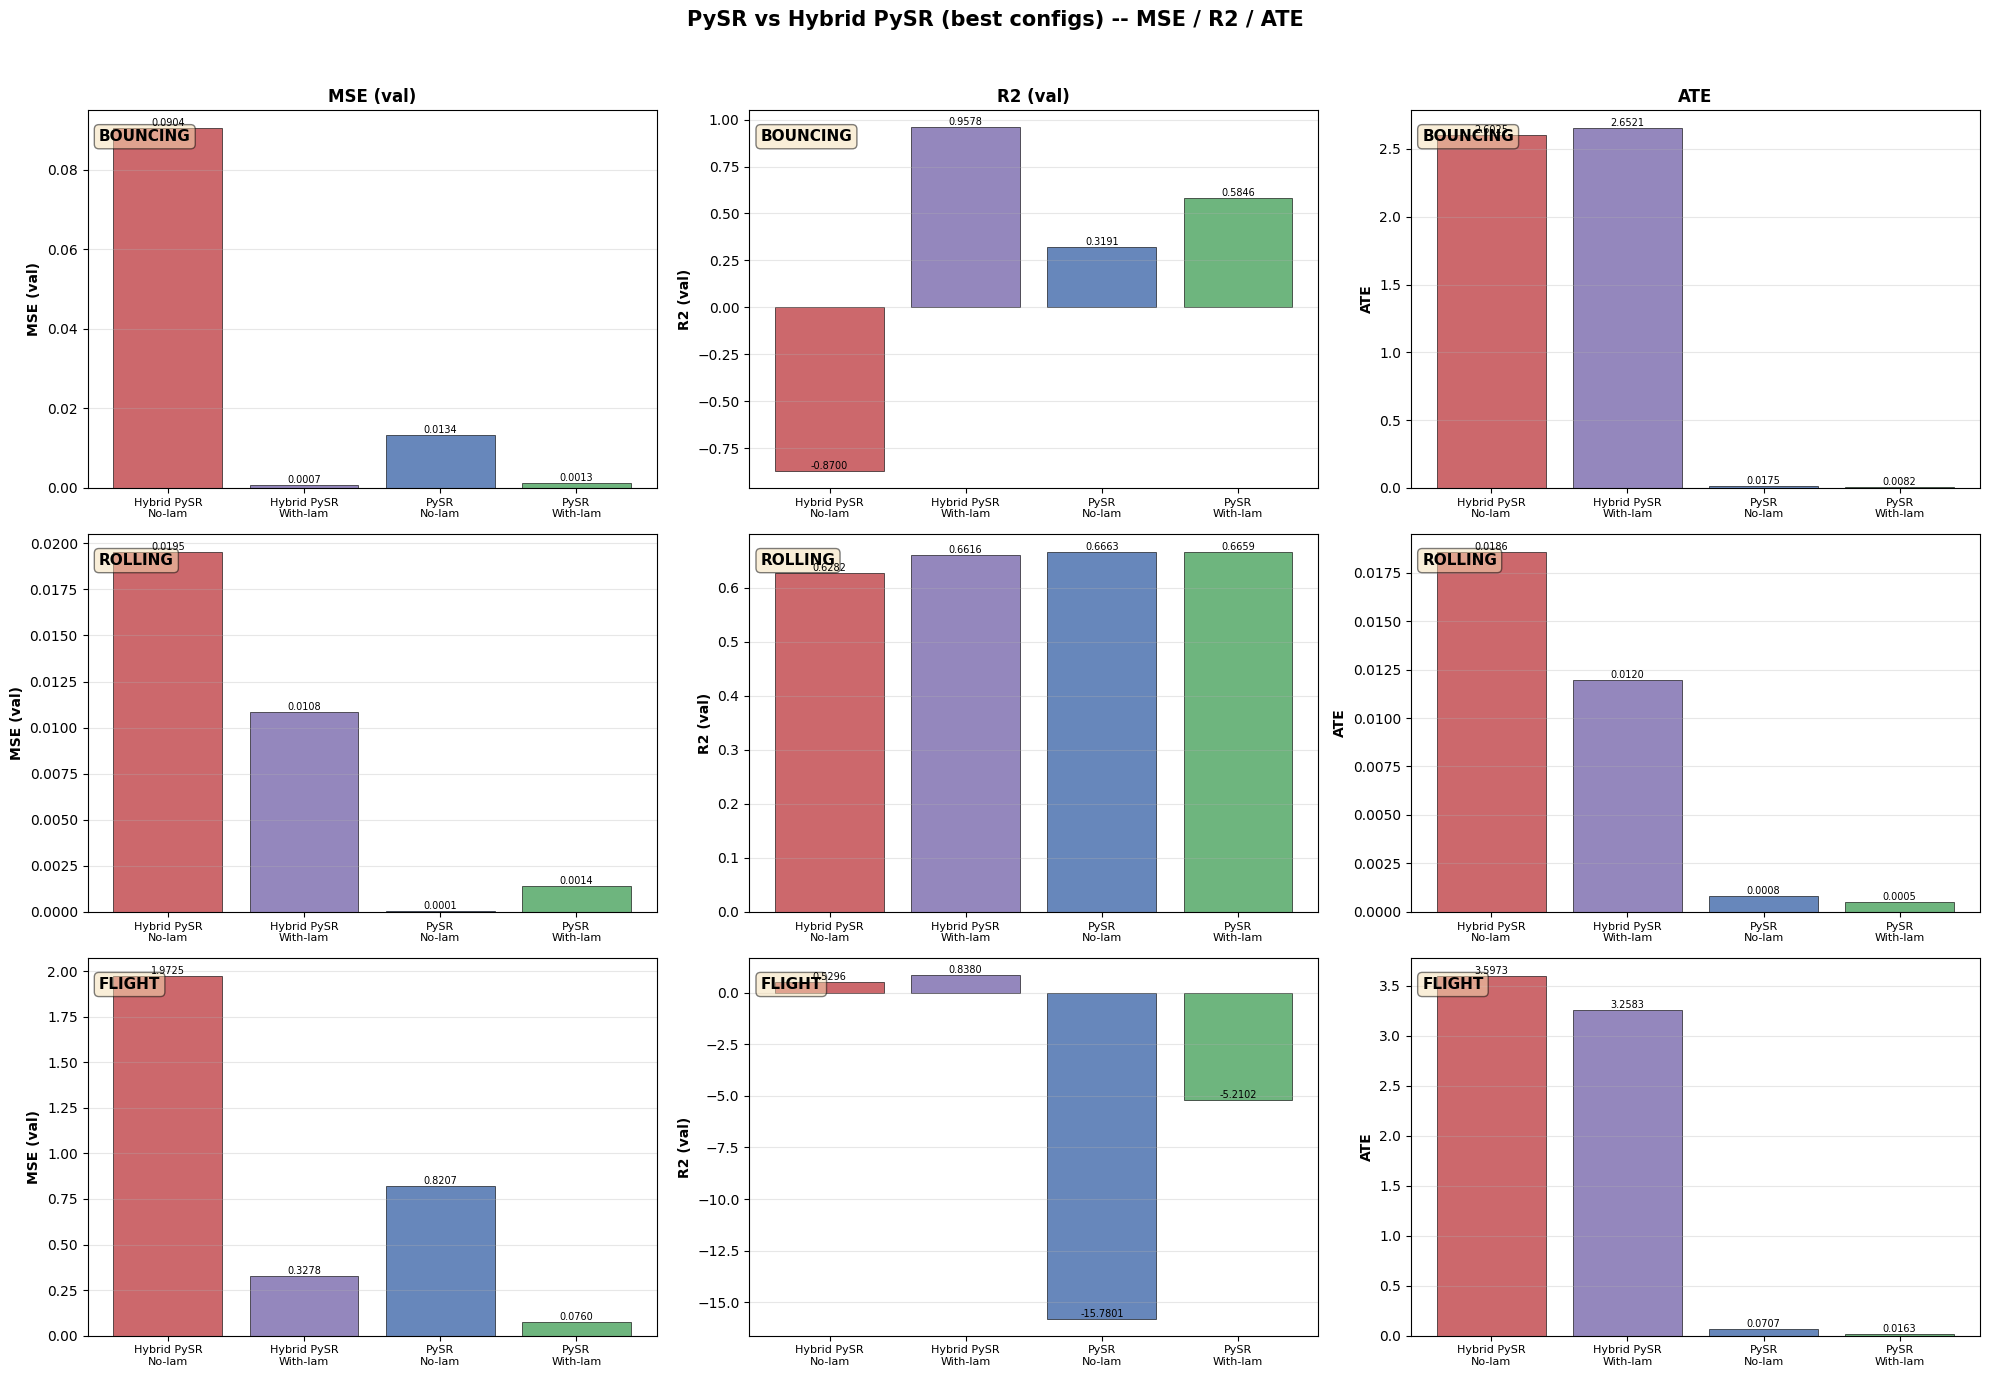

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.suptitle('PySR vs Hybrid PySR (best configs) -- MSE / R2 / ATE', fontsize=15, fontweight='bold')

# pick best config per (algo, lib, regime, dof) by ATE
idx_best = df_pysr.groupby(['algorithm','library','regime','dof'])['ATE'].idxmin()
df_best = df_pysr.loc[idx_best].copy()

metrics = [('MSE_val', 'MSE (val)'), ('R2_val', 'R2 (val)'), ('ATE', 'ATE')]
for col, (metric, ylabel) in enumerate(metrics):
    for row, regime in enumerate(REGIMES):
        ax = axes[row, col]
        sub = df_best[df_best['regime'] == regime]
        groups = sub.groupby(['algorithm','library'])[metric].mean().reset_index()
        labels = [f'{a}\n{l}' for a, l in zip(groups['algorithm'], groups['library'])]
        cmap = {'PySR/No-lam':'#4C72B0', 'PySR/With-lam':'#55A868',
                'Hybrid PySR/No-lam':'#C44E52', 'Hybrid PySR/With-lam':'#8172B2'}
        colors = [cmap.get(f'{a}/{l}', 'grey') for a, l in zip(groups['algorithm'], groups['library'])]
        bars = ax.bar(range(len(groups)), groups[metric], color=colors,
                      alpha=0.85, edgecolor='black', linewidth=0.5)
        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel(ylabel, fontweight='bold')
        if row == 0: ax.set_title(ylabel, fontsize=12, fontweight='bold')
        ax.text(0.02, 0.95, regime.upper(), transform=ax.transAxes, fontsize=11,
                fontweight='bold', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, groups[metric]):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                    f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(PROJ, 'pysr_internal_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## S7 Best Equations

In [23]:
print('=' * 90)
print('BEST EQUATIONS (by ATE per algorithm x regime x DOF)')
print('=' * 90)

for algo in ['PySR', 'Hybrid PySR']:
    print(f'\n--- {algo} ---')
    sub = df_pysr[df_pysr['algorithm'] == algo]
    for regime in REGIMES:
        print(f'\n  {regime.upper()}:')
        for dof in DOF_LABELS:
            rows = sub[(sub['regime'] == regime) & (sub['dof'] == dof)]
            if len(rows) == 0: continue
            best = rows.loc[rows['ATE'].idxmin()]
            eq = best['equation']
            if len(eq) > 95: eq = eq[:92] + '...'
            print(f'    {dof} [{best["library"]} p={best["parsimony"]} ms={best["maxsize"]}]'
                  f' ATE={best["ATE"]:.4f}({best["ate_grade"]}) R2={best["R2_val"]:.3f}')
            print(f'      {eq}')

BEST EQUATIONS (by ATE per algorithm x regime x DOF)

--- PySR ---

  BOUNCING:
    a_x [With-lam p=0.1 ms=25] ATE=0.0015(A) R2=0.754
      (-(-0.044564184)*thetadot*(lambda_N + thetadot + cos(ydot) - 1*0.28159285)*cos(ydot) - 0.006...
    a_y [With-lam p=0.1 ms=25] ATE=0.0194(B) R2=0.000
      (-1*(-0.3196009) + cos(cos(xdot + cos(cos(sin(xdot) + 0.16590402)**2)/(-lambda_N - 0.1830174...
    a_theta [No-lam p=0.1 ms=25] ATE=0.0010(A) R2=0.999
      xddot*0.2692773*(y/(-0.23879832) - yddot - 1*0.12452908)/(-yddot - 0.32617772*(-yddot - yddo...

  ROLLING:
    a_x [With-lam p=0.1 ms=25] ATE=0.0004(A) R2=0.998
      ((ydot + 0.5769247)*cos(thetadot*(-1.1832663)) + 0.90261966)*cos(theta)
    a_y [No-lam p=0.001 ms=15] ATE=0.0000(A) R2=0.000
      ydot/0.037288435
    a_theta [With-lam p=0.01 ms=15] ATE=0.0011(A) R2=0.999
      (lambda_F + (lambda_N*(-0.59862477) - 1*0.05635163)*cos(theta))*2.50695

  FLIGHT:
    a_x [With-lam p=0.01 ms=15] ATE=0.0114(B) R2=0.820
      (5.497934 - lambda_F

## S8 Cross-Method Comparison -- PySR vs SINDy Pipeline

Load SINDy sweep results (3600 rows) and compare best configs head-to-head.

In [24]:
sindy_csv = os.path.join(PROJ, 'pipeline', 'full_sweep_results.csv')
df_sindy = pd.read_csv(sindy_csv)
print(f'SINDy results: {len(df_sindy)} rows, algorithms: {list(df_sindy["algorithm"].unique())}')

# best SINDy config per (algo, regime, dof)
sindy_best = []
for algo in df_sindy['algorithm'].unique():
    sub = df_sindy[df_sindy['algorithm'] == algo]
    for regime in REGIMES:
        for dof in DOF_LABELS:
            rows = sub[(sub['regime']==regime) & (sub['dof']==dof)].dropna(subset=['ATE'])
            if len(rows) == 0: continue
            b = rows.loc[rows['ATE'].idxmin()]
            sindy_best.append({
                'algorithm': b['algorithm'], 'regime': regime, 'dof': dof,
                'library': b['library'],
                'MSE_val': b['MSE_val'], 'MSE_test': b['MSE_test'],
                'R2_val': b.get('R2_val', np.nan), 'R2_test': b['R2_test'],
                'ATE': b['ATE'], 'ate_grade': b['ate_grade'],
            })

# best PySR config per (algo, regime, dof)
pysr_best = []
for algo in ['PySR', 'Hybrid PySR']:
    sub = df_pysr[df_pysr['algorithm'] == algo]
    for regime in REGIMES:
        for dof in DOF_LABELS:
            rows = sub[(sub['regime']==regime) & (sub['dof']==dof)].dropna(subset=['ATE'])
            if len(rows) == 0: continue
            b = rows.loc[rows['ATE'].idxmin()]
            pysr_best.append({
                'algorithm': b['algorithm'], 'regime': regime, 'dof': dof,
                'library': b['library'],
                'MSE_val': b['MSE_val'], 'MSE_test': b['MSE_test'],
                'R2_val': b['R2_val'], 'R2_test': b['R2_test'],
                'ATE': b['ATE'], 'ate_grade': b['ate_grade'],
            })

df_cross = pd.concat([pd.DataFrame(sindy_best), pd.DataFrame(pysr_best)], ignore_index=True)
print(f'\nCross-comparison: {len(df_cross)} best configs')
print(df_cross.groupby('algorithm')[['MSE_val','R2_val','ATE']].mean().to_string())

SINDy results: 3600 rows, algorithms: ['SINDy', 'Lagrange', 'Hybrid']

Cross-comparison: 45 best configs
              MSE_val    R2_val       ATE
algorithm                                
Hybrid       1.116605  0.762458  0.004362
Hybrid PySR  0.643305  0.235569  1.934222
Lagrange     0.487520  0.126306  0.004506
PySR         0.026258 -1.320000  0.008031
SINDy        0.047072  0.676112  0.006588


## S8b Cross-Method Plots

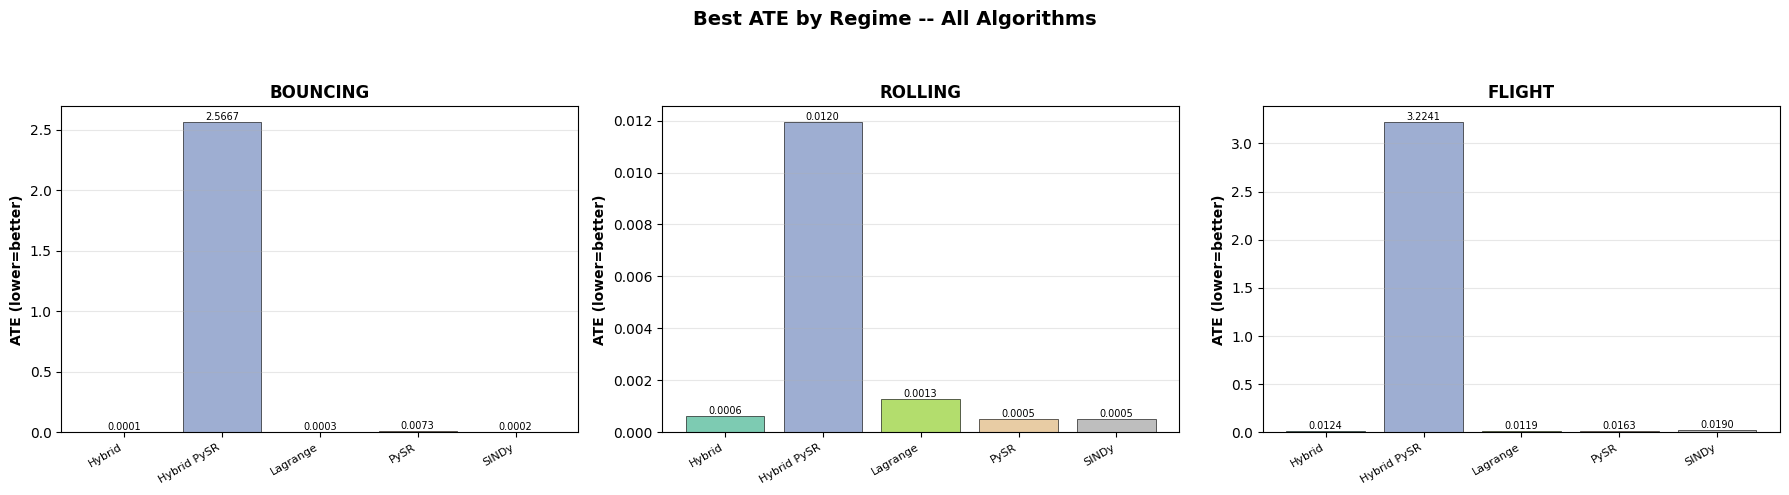

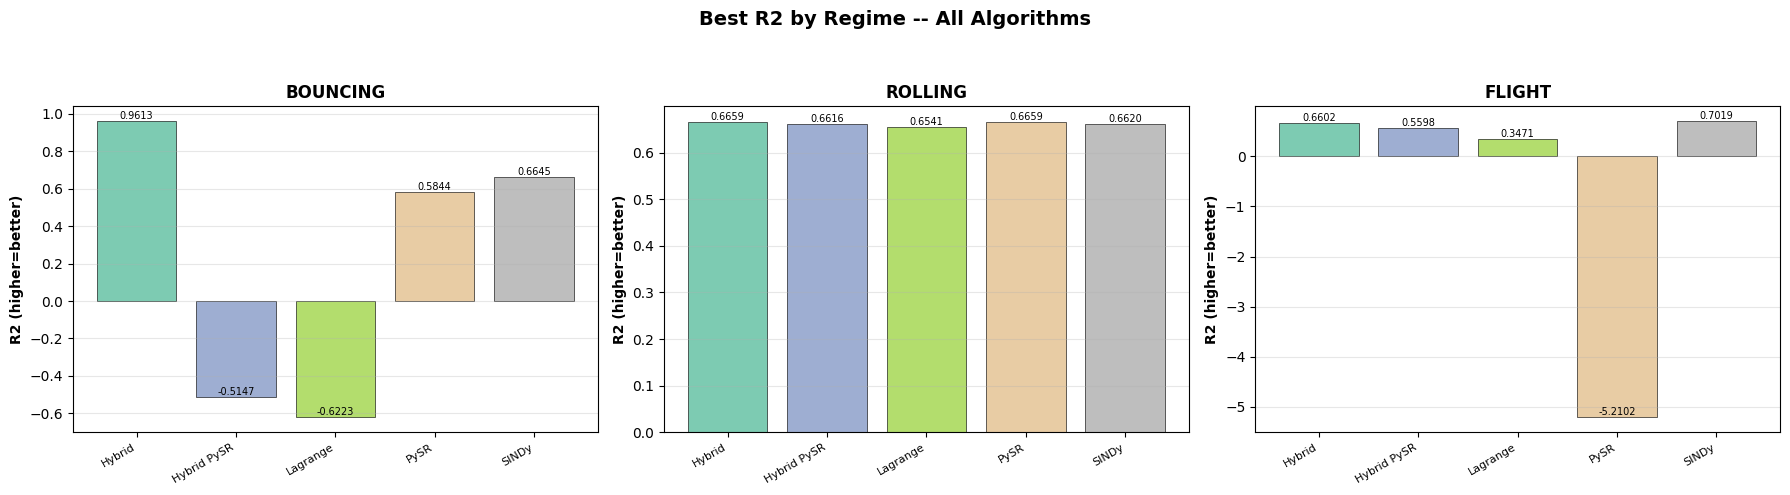

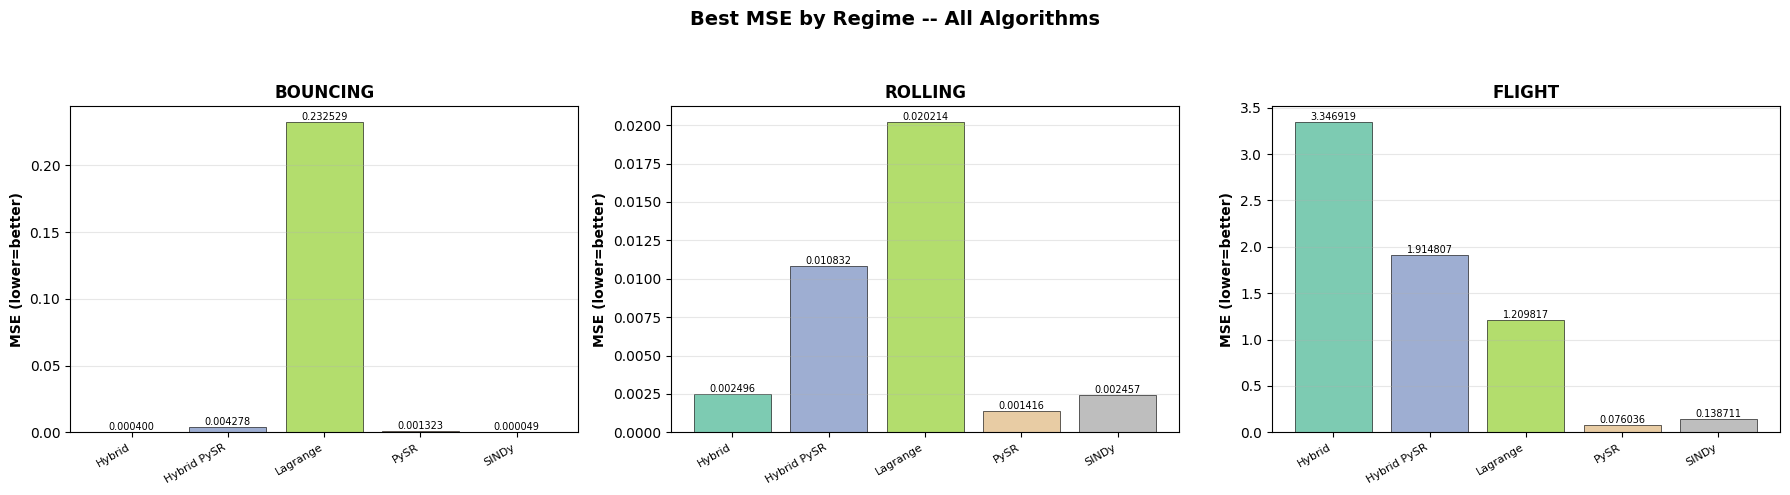

Cross-method plots saved.


In [25]:
all_algos = sorted(df_cross['algorithm'].unique())
cmap = plt.cm.Set2
acolors = {a: cmap(i / max(len(all_algos)-1, 1)) for i, a in enumerate(all_algos)}

for metric, ylabel, title_word in [
    ('ATE', 'ATE (lower=better)', 'ATE'),
    ('R2_val', 'R2 (higher=better)', 'R2'),
    ('MSE_val', 'MSE (lower=better)', 'MSE'),
]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Best {title_word} by Regime -- All Algorithms', fontsize=14, fontweight='bold')
    for i, regime in enumerate(REGIMES):
        ax = axes[i]
        sub = df_cross[df_cross['regime'] == regime]
        vals = sub.groupby('algorithm')[metric].mean().reindex(all_algos)
        bars = ax.bar(range(len(all_algos)), vals.values,
                      color=[acolors[a] for a in all_algos],
                      edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.set_xticks(range(len(all_algos)))
        ax.set_xticklabels(all_algos, fontsize=8, rotation=30, ha='right')
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.set_title(regime.upper(), fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        fmt = '.6f' if 'MSE' in metric else '.4f'
        for bar, val in zip(bars, vals.values):
            if np.isfinite(val):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                        f'{val:{fmt}}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(os.path.join(PROJ, f'cross_method_{title_word.lower()}.png'),
               dpi=150, bbox_inches='tight')
    plt.show()
print('Cross-method plots saved.')

## S9 ATE Grade Heatmap -- All Methods

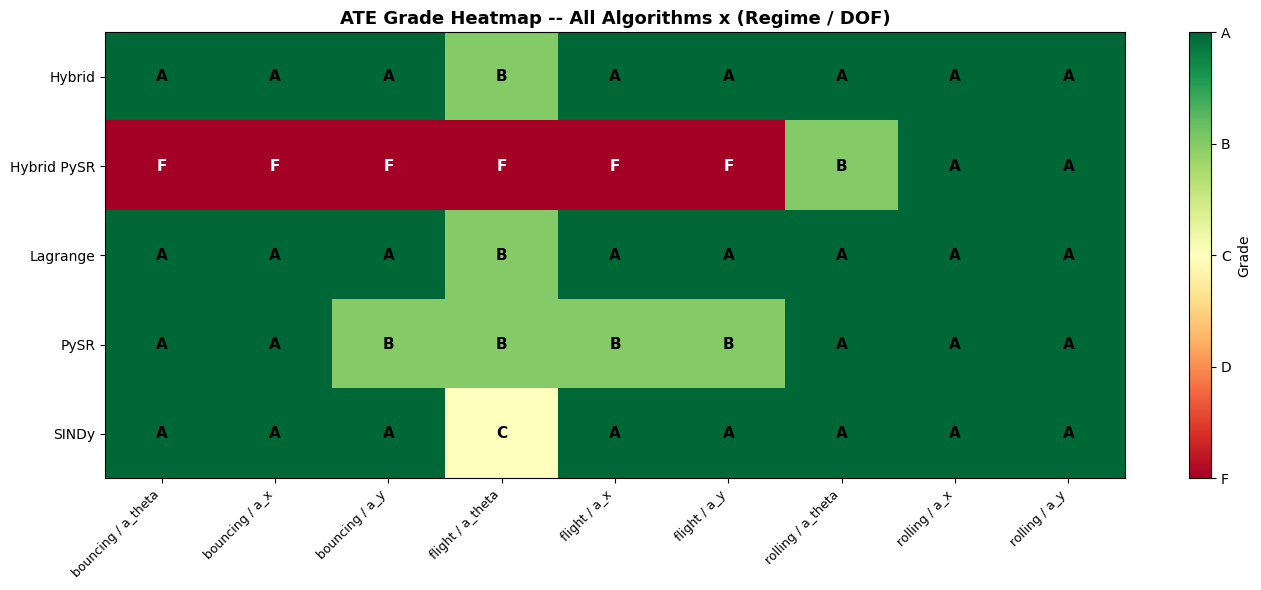

In [26]:
grade_map = {'A': 4, 'B': 3, 'C': 2, 'D': 1, 'F': 0}
grade_labels = {4: 'A', 3: 'B', 2: 'C', 1: 'D', 0: 'F'}

df_cross['grade_num'] = df_cross['ate_grade'].map(grade_map)
df_cross['label'] = df_cross['regime'] + ' / ' + df_cross['dof']
pivot = df_cross.pivot_table(index='algorithm', columns='label',
                             values='grade_num', aggfunc='max')

fig, ax = plt.subplots(figsize=(14, 4 + 0.4 * len(all_algos)))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0, vmax=4, aspect='auto')
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels(pivot.index, fontsize=10)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if np.isfinite(val):
            lbl = grade_labels.get(int(val), '?')
            ax.text(j, i, lbl, ha='center', va='center', fontsize=11,
                    fontweight='bold', color='white' if val <= 1 else 'black')
ax.set_title('ATE Grade Heatmap -- All Algorithms x (Regime / DOF)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, ticks=[0,1,2,3,4], label='Grade',
             format=plt.FuncFormatter(lambda x, _: grade_labels.get(int(x), '')))
plt.tight_layout()
plt.savefig(os.path.join(PROJ, 'cross_method_grade_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## S10 Final Summary

In [27]:
print('=' * 80)
print('  FINAL SUMMARY -- ALL ALGORITHMS')
print('=' * 80)

algo_summary = df_cross.groupby('algorithm').agg(
    ATE_mean=('ATE', 'mean'), ATE_min=('ATE', 'min'),
    R2_mean=('R2_val', 'mean'), R2_max=('R2_val', 'max'),
    MSE_mean=('MSE_val', 'mean'), MSE_min=('MSE_val', 'min'),
).sort_values('ATE_mean')

print('\n  Ranked by mean ATE (lower is better):')
print(algo_summary.to_string())

best_ate = algo_summary.index[0]
best_r2  = algo_summary['R2_mean'].idxmax()
best_mse = algo_summary['MSE_mean'].idxmin()
print(f'\n  Best by ATE:  {best_ate} ({algo_summary.loc[best_ate, "ATE_mean"]:.4f})')
print(f'  Best by R2:   {best_r2} ({algo_summary.loc[best_r2, "R2_mean"]:.4f})')
print(f'  Best by MSE:  {best_mse} ({algo_summary.loc[best_mse, "MSE_mean"]:.6f})')

print(f'\n--- Per-regime winners (best ATE) ---')
for regime in REGIMES:
    sub = df_cross[df_cross['regime'] == regime]
    w = sub.loc[sub['ATE'].idxmin()]
    print(f'  {regime.upper():10s} -> {w["algorithm"]:14s} ATE={w["ATE"]:.4f}({w["ate_grade"]})')

print(f'\n--- Lambda effect (PySR algorithms) ---')
for algo in ['PySR', 'Hybrid PySR']:
    sub = df_pysr[df_pysr['algorithm'] == algo]
    nl = sub[sub['library'] == 'No-lam']['ATE'].mean()
    wl = sub[sub['library'] == 'With-lam']['ATE'].mean()
    delta = ((nl - wl) / nl * 100) if nl > 0 else 0
    better = 'With-lam' if wl < nl else 'No-lam'
    print(f'  {algo:14s}: No-lam={nl:.4f} With-lam={wl:.4f} -> {better} ({abs(delta):.1f}%)')

print(f'\n--- Hyperparameter effect ---')
for param in ['parsimony', 'maxsize']:
    print(f'\n  {param}:')
    grp = df_pysr.groupby(param)['ATE'].agg(['mean', 'min'])
    for val, row in grp.iterrows():
        print(f'    {val}: mean_ATE={row["mean"]:.4f} min_ATE={row["min"]:.4f}')

print(f'\n--- ATE Grade Distribution ---')
gct = pd.crosstab(df_cross['algorithm'], df_cross['ate_grade'])
for g in ['A','B','C','D','F']:
    if g not in gct.columns: gct[g] = 0
print(gct[['A','B','C','D','F']].to_string())

print(f'\n{"="*80}')
print(f'  PySR configs:     {len(df_pysr)}')
print(f'  Cross-comparison: {len(df_cross)}')
print(f'  Results:          pysr_sweep_results.csv')
print(f'{"="*80}')

  FINAL SUMMARY -- ALL ALGORITHMS

  Ranked by mean ATE (lower is better):
             ATE_mean       ATE_min   R2_mean    R2_max  MSE_mean       MSE_min
algorithm                                                                      
Hybrid       0.004362  8.558712e-08  0.762458  0.999990  1.116605  1.011295e-10
Lagrange     0.004506  0.000000e+00  0.126306  0.997778  0.487520  2.517822e-36
SINDy        0.006588  1.320445e-13  0.676112  0.998266  0.047072  4.156052e-22
PySR         0.008031  0.000000e+00 -1.320000  0.999327  0.026258  5.209533e-35
Hybrid PySR  1.934222  0.000000e+00  0.235569  0.998902  0.643305  2.154374e-35

  Best by ATE:  Hybrid (0.0044)
  Best by R2:   Hybrid (0.7625)
  Best by MSE:  PySR (0.026258)

--- Per-regime winners (best ATE) ---
  BOUNCING   -> Lagrange       ATE=0.0000(A)
  ROLLING    -> Lagrange       ATE=0.0000(A)
  FLIGHT     -> Lagrange       ATE=0.0001(A)

--- Lambda effect (PySR algorithms) ---
  PySR          : No-lam=0.0882 With-lam=0.0468 -> Wi

## S11 Structural Term Recovery — Physics Check

Match PySR discovered equations against known physics terms to compute structural **recall** & **precision**.
Mirrors the SINDy pipeline's TRUE vs DISCOVERED analysis.

- **[OK]** — true physics term found in discovered equation (with coefficient)
- **[--]** — true physics term missing from discovered equation
- **[CF]** — contact force term (lambda_F / lambda_N), valid only in With-lam runs
- **[??]** — spurious additive terms with no physics counterpart

> PySR operates in **physical space** (no StandardScaler normalisation), so discovered coefficients
> are directly comparable to TRUE_EOMS values — no denormalisation step needed.


TRUE physics patterns defined.
  a_x: ['sin(theta) thetaddot', 'cos(theta) thetadot^2']
  a_y: ['1', 'sin(theta) thetadot^2', 'cos(theta) thetaddot']
  a_theta: ['sin(theta) xddot', 'cos(theta) yddot', 'cos(theta)']
Computing structural recall for 216 rows (numerical matching — fast)...
  [  1/216]  PySR        | bouncing | a_x  0.0s elapsed  ETA 0s  eq: cos(theta)*thetadot**2*0.061632205
  [ 11/216]  Hybrid PySR | bouncing | a_y  0.2s elapsed  ETA 4s  eq: cos(thetaddot)**64/(-0.95281804)
  [ 21/216]  PySR        | bouncing | a_theta  0.3s elapsed  ETA 3s  eq: xddot*sin(sin(sin(lambda_N)))/(-0.13223867)
  [ 31/216]  Hybrid PySR | rolling  | a_x  0.5s elapsed  ETA 3s  eq: cos(theta)*thetadot*thetadot*0.05470025
  [ 41/216]  PySR        | rolling  | a_y  1.0s elapsed  ETA 4s  eq: sin(xdot*ydot*(0.067946315 - (0.067946315 - x)*sin(xdot*ydot...
  [ 51/216]  Hybrid PySR | rolling  | a_theta  1.2s elapsed  ETA 4s  eq: (2.0575352 - 1.16064904119229*(-xddot + ydot)**2)*(xddot*xdo...
  [ 61/216

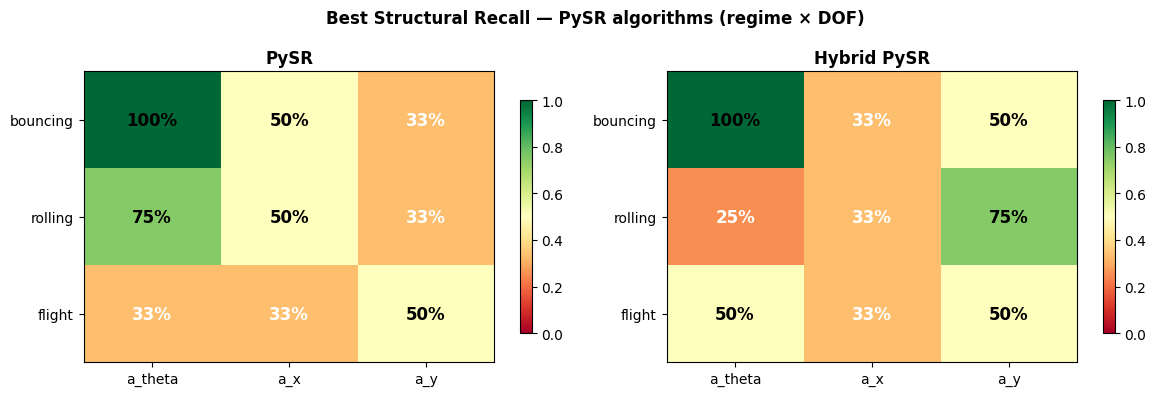

Recall heatmap saved.


In [28]:

# ── S11a  TRUE physics definitions ────────────────────────────────────────────
import sympy as sp

_sv = {n: sp.Symbol(n) for n in [
    'x', 'y', 'theta', 'xdot', 'ydot', 'thetadot',
    'xddot', 'yddot', 'thetaddot', 'lambda_N', 'lambda_F'
]}
_th, _thd, _thdd = _sv['theta'], _sv['thetadot'], _sv['thetaddot']
_xdd, _ydd       = _sv['xddot'],  _sv['yddot']
_lN, _lF         = _sv['lambda_N'], _sv['lambda_F']

# (key, sympy_pattern_or_None, true_coeff, is_constant)
TRUE_EOMS_PySR = {
    'a_x': [
        ('sin(theta) thetaddot',  sp.sin(_th)*_thdd,    0.060, False),
        ('cos(theta) thetadot^2', sp.cos(_th)*_thd**2,  0.060, False),
    ],
    'a_y': [
        ('1',                     None,                  1.000, True),   # gravity/constant
        ('sin(theta) thetadot^2', sp.sin(_th)*_thd**2,  0.060, False),
        ('cos(theta) thetaddot',  sp.cos(_th)*_thdd,    0.060, False),
    ],
    'a_theta': [
        ('sin(theta) xddot', sp.sin(_th)*_xdd, 1.852, False),
        ('cos(theta) yddot', sp.cos(_th)*_ydd, 1.852, False),
        ('cos(theta)',        sp.cos(_th),      1.852, False),
    ],
}
TRUE_CONTACT_PySR = {
    'a_x':     [('lambda_F', _lF, 1/1.5,          False)],
    'a_y':     [('lambda_N', _lN, 1/1.5,          False)],
    'a_theta': [('lambda_F', _lF, 1/(1.5*0.18),   False)],
}

# Sample points for numerical coefficient matching (avoids slow sp.simplify)
_SAMPLE_SEEDS = [
    {s: (i + 1) * (0.31 + k * 0.19) for i, s in enumerate(_sv.values())}
    for k in range(4)
]

def _coeff_of(expanded_expr, pattern, is_const=False):
    """Return scalar c such that c*pattern is an additive term in expanded_expr, else 0.
    Uses sp.cancel (fast) then numerical sampling — avoids slow sp.simplify."""
    if is_const:
        for t in sp.Add.make_args(expanded_expr):
            if t.is_number:
                return float(t)
        return 0.0
    for t in sp.Add.make_args(expanded_expr):
        # Fast path: sp.cancel handles polynomial/rational simplification quickly
        try:
            r = sp.cancel(t / pattern)
            if r.is_number and abs(float(r)) > 1e-10:
                return float(r)
        except Exception:
            pass
        # Numerical fallback: evaluate t and pattern at multiple random points
        # and check if their ratio is consistently the same real constant.
        try:
            ratios = []
            for subs in _SAMPLE_SEEDS:
                tp = complex(t.evalf(subs=subs))
                pp = complex(pattern.evalf(subs=subs))
                if abs(pp) > 1e-8:
                    ratios.append(tp / pp)
            if len(ratios) >= 3:
                reals = [r.real for r in ratios]
                imags = [r.imag for r in ratios]
                if (max(reals) - min(reals) < 1e-5
                        and all(abs(im) < 1e-5 for im in imags)
                        and abs(reals[0]) > 1e-10):
                    return reals[0]
        except Exception:
            pass
    return 0.0

def parse_match_pysr(eq_str, dof, with_lambda=False):
    """
    Parse PySR equation string; match against TRUE_EOMS_PySR terms.
    Returns (matched, missed, n_disc_terms)
      matched = [(key, c_disc, c_true, rel_err%)]
      missed  = [key]
    """
    true_list = list(TRUE_EOMS_PySR.get(dof, []))
    if with_lambda:
        true_list += list(TRUE_CONTACT_PySR.get(dof, []))
    try:
        expr = sp.parse_expr(str(eq_str), local_dict=_sv)
        exp  = sp.expand(expr)
    except Exception:
        return [], [k for k, *_ in true_list], 0

    matched, missed = [], []
    for key, pattern, c_true, is_const in true_list:
        c_disc = _coeff_of(exp, pattern, is_const)
        if abs(c_disc) > 1e-10:
            re = (c_disc - c_true) / abs(c_true) * 100.0
            matched.append((key, c_disc, c_true, re))
        else:
            missed.append(key)

    n_disc = len(sp.Add.make_args(exp))
    return matched, missed, n_disc

print('TRUE physics patterns defined.')
for dof in DOF_LABELS:
    print(f'  {dof}: {[k for k,*_ in TRUE_EOMS_PySR[dof]]}')

# ── S11b  Compute recall & precision for every PySR row ───────────────────────
try:
    _ = df_pysr
except NameError:
    df_pysr = pd.read_csv(os.path.join(PROJ, 'pysr_sweep_results.csv'))
    print(f'Loaded {len(df_pysr)} rows from pysr_sweep_results.csv')

# Skip expensive SymPy recomputation if structural columns already present
_structural_cols = ['recall', 'precision', 'n_correct', 'n_true', 'n_disc']
if all(c in df_pysr.columns for c in _structural_cols):
    print(f'Structural metrics already computed ({len(df_pysr)} rows) — skipping recomputation.')
    print('(Delete recall/precision columns from df_pysr to force recompute.)')
else:
    n_total = len(df_pysr)
    print(f'Computing structural recall for {n_total} rows (numerical matching — fast)...')
    rec_rows = []
    t0_s11 = time.time()
    for i, (_, row) in enumerate(df_pysr.iterrows()):
        dof      = row['dof']
        eq       = str(row['equation'])
        has_lam  = str(row['library']) == 'With-lam'
        true_lst = list(TRUE_EOMS_PySR.get(dof, []))
        if has_lam:
            true_lst += list(TRUE_CONTACT_PySR.get(dof, []))
        n_true = len(true_lst)

        # Per-row progress: print every 10 rows and always the last
        if i % 10 == 0 or i == n_total - 1:
            elapsed = time.time() - t0_s11
            rate = (i + 1) / elapsed if elapsed > 0 else float('inf')
            eta = (n_total - i - 1) / rate if rate > 0 else 0
            eq_short = eq[:60] + '...' if len(eq) > 60 else eq
            print(f'  [{i+1:3d}/{n_total}]  {row["algorithm"]:11s} | {row["regime"]:8s} | '
                  f'{dof}  {elapsed:.1f}s elapsed  ETA {eta:.0f}s  eq: {eq_short}',
                  flush=True)

        matched, missed, n_disc = parse_match_pysr(eq, dof, has_lam)
        n_correct  = len(matched)
        n_spurious = max(0, n_disc - n_correct)
        rec_rows.append({
            'recall':    n_correct / n_true if n_true > 0 else 0.0,
            'precision': n_correct / (n_correct + n_spurious) if (n_correct + n_spurious) > 0 else 0.0,
            'n_correct': n_correct,
            'n_true':    n_true,
            'n_disc':    n_disc,
        })

    df_rec = pd.DataFrame(rec_rows)
    for col in df_rec.columns:
        df_pysr[col] = df_rec[col].values
    df_pysr.to_csv(os.path.join(PROJ, 'pysr_sweep_results.csv'), index=False)
    total_s11 = time.time() - t0_s11
    print(f'Structural metrics computed and saved. ({total_s11:.1f}s total)')

print(f'\nStructural metrics ready for {len(df_pysr)} configs')
print('\n--- Mean recall / precision by algorithm ---')
print(df_pysr.groupby('algorithm')[['recall','precision']].mean().round(3).to_string())

# ── Recall heatmap (best per regime × DOF) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Best Structural Recall — PySR algorithms (regime × DOF)', fontweight='bold')
for ax, algo in zip(axes, ['PySR', 'Hybrid PySR']):
    sub = df_pysr[df_pysr['algorithm'] == algo]
    piv = sub.groupby(['regime', 'dof'])['recall'].max().unstack(fill_value=0)
    for r in REGIMES:
        if r not in piv.index: piv.loc[r] = 0
    piv = piv.reindex(REGIMES)
    im = ax.imshow(piv.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, fontsize=10)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index,   fontsize=10)
    ax.set_title(algo, fontweight='bold')
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            ax.text(j, i, f'{v:.0%}', ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if v < 0.4 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(PROJ, 'pysr_recall_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Recall heatmap saved.')


In [29]:

# ── S11c  TRUE vs DISCOVERED — best config per algorithm × regime × DOF ───────
_contact_keys = {dof: {k for k, *_ in TRUE_CONTACT_PySR.get(dof, [])}
                 for dof in DOF_LABELS}

for algo in ['PySR', 'Hybrid PySR']:
    print(f'\n{"═"*92}')
    print(f'  {algo}')
    print(f'{"═"*92}')
    sub_algo = df_pysr[df_pysr['algorithm'] == algo]

    for regime in REGIMES:
        print(f'\n  ── {regime.upper()} ──')
        sub_reg = sub_algo[sub_algo['regime'] == regime]

        for dof in DOF_LABELS:
            sub_dof = sub_reg[sub_reg['dof'] == dof]
            if sub_dof.empty:
                continue
            best     = sub_dof.loc[sub_dof['recall'].idxmax()]
            eq       = str(best['equation'])
            has_lam  = str(best['library']) == 'With-lam'
            recall   = float(best['recall'])
            prec     = float(best['precision'])
            n_c      = int(best['n_correct'])
            n_t      = int(best['n_true'])
            n_d      = int(best['n_disc'])
            n_spur   = max(0, n_d - n_c)

            mse_tr = best.get('MSE_train', best.get('MSE_val', float('nan')))
            mse_te = best.get('MSE_test', float('nan'))
            ate_v  = best.get('ATE', float('nan'))
            grade  = best.get('ate_grade', '?')

            matched, missed, _ = parse_match_pysr(eq, dof, has_lam)
            matched_d = {k: (cd, ct, re) for k, cd, ct, re in matched}

            true_lst = list(TRUE_EOMS_PySR.get(dof, []))
            if has_lam:
                true_lst += list(TRUE_CONTACT_PySR.get(dof, []))

            print(f'\n    {dof}  [{best["library"]}  p={best["parsimony"]}  ms={best["maxsize"]}]')
            print(f'    recall={recall:.0%}  precision={prec:.0%}  '
                  f'n_matched={n_c}/{n_t}  n_disc_terms={n_d}  '
                  f'({n_spur} spurious)')
            print(f'    MSE_train={mse_tr:.4g}  MSE_test={mse_te:.4g}  '
                  f'ATE={ate_v:.4f}({grade})')

            for key, pattern, c_true, is_const in true_lst:
                is_cf = key in _contact_keys.get(dof, set())
                prefix = '[CF]' if is_cf else '[OK]'
                if key in matched_d:
                    cd, ct, re = matched_d[key]
                    sign_warn = '  ⚠ SIGN FLIP' if (cd * ct) < 0 else ''
                    print(f'      {prefix} {key:<32s}  true={c_true:+.4f}  '
                          f'disc={cd:+.6f}  err={re:+.1f}%{sign_warn}')
                else:
                    print(f'      [--] {key:<32s}  true={c_true:+.4f}  -- MISSING --')

            if n_spur > 0:
                print(f'      [??] {n_spur} spurious additive term(s) in discovered expression')

            eq_disp = eq[:112] + '...' if len(eq) > 112 else eq
            print(f'      EQ:  {eq_disp}')



════════════════════════════════════════════════════════════════════════════════════════════
  PySR
════════════════════════════════════════════════════════════════════════════════════════════

  ── BOUNCING ──

    a_x  [No-lam  p=0.001  ms=15]
    recall=50%  precision=100%  n_matched=1/2  n_disc_terms=1  (0 spurious)
    MSE_train=7.357e-05  MSE_test=0.003581  ATE=0.0336(B)
      [--] sin(theta) thetaddot              true=+0.0600  -- MISSING --
      [OK] cos(theta) thetadot^2             true=+0.0600  disc=+0.061632  err=+2.7%
      EQ:  cos(theta)*thetadot**2*0.061632205

    a_y  [No-lam  p=0.1  ms=25]
    recall=33%  precision=50%  n_matched=1/3  n_disc_terms=2  (1 spurious)
    MSE_train=0.005281  MSE_test=1.204  ATE=0.1309(C)
      [OK] 1                                 true=+1.0000  disc=-0.971748  err=-197.2%  ⚠ SIGN FLIP
      [--] sin(theta) thetadot^2             true=+0.0600  -- MISSING --
      [--] cos(theta) thetaddot              true=+0.0600  -- MISSING --
      [

## S12 Coefficient Accuracy — Physical Values

For every best-recall config, compare the **discovered coefficient** to the **true physical value**.

> **Key advantage over SINDy**: PySR fits directly in physical (un-normalised) space, so
> `c_discovered` can be compared to `c_true` without any denormalisation step.
> In SINDy we needed `c_phys = c_norm * σ_y / σ_feature` to recover physical units.

Expected true coefficients (hoop physics, m=1.5 kg, r=0.18 m):
- **a_x**: sin(θ)θ̈ = 0.060, cos(θ)θ̇² = 0.060
- **a_y**: 1 = 1.000, sin(θ)θ̇² = 0.060, cos(θ)θ̈ = 0.060
- **a_θ**: sin(θ)ẍ = 1.852, cos(θ)ÿ = 1.852, cos(θ) = 1.852
- **contact**: λ_F / λ_N = 0.667 (= 1/1.5), λ_F(θ) = 3.704


=== PySR COEFFICIENT ACCURACY (physical space — no denormalisation needed) ===

Total matched term comparisons : 30
Mean  |rel err|                : 106.2%
Median|rel err|                : 100.0%
Max   |rel err|                : 455.6%
Terms within  5%               : 3%
Terms within 10%               : 10%
Terms within 20%               : 10%
Sign errors                    : 13 / 30

--- Mean |rel err%| per algorithm ---
algo
Hybrid PySR    116.6
PySR            94.4

--- Mean |rel err%| per DOF ---
dof
a_theta     98.2
a_x        106.5
a_y        115.7

--- Mean |rel err%| per regime ---
regime
bouncing    101.1
flight      139.3
rolling      82.1

--- Worst 5 coefficient estimates ---
       algo   regime     dof                  term   c_true    c_disc    rel_err%
Hybrid PySR   flight     a_x cos(theta) thetadot^2 0.060000  0.333333  455.555556
       PySR  rolling a_theta      cos(theta) yddot 1.852000 -1.875903 -201.290657
       PySR bouncing     a_y                     1 1.0000

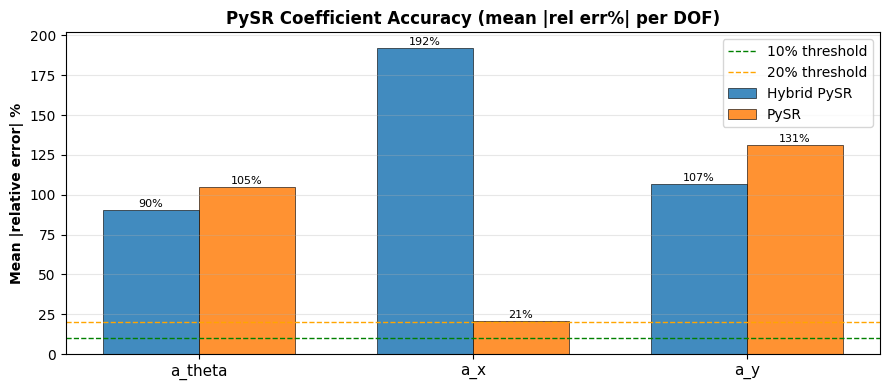

Coefficient accuracy chart saved.


In [30]:

# ── S12  Coefficient accuracy — best-recall config per algo × regime × DOF ────
coef_rows = []
for algo in ['PySR', 'Hybrid PySR']:
    sub_algo = df_pysr[df_pysr['algorithm'] == algo]
    for regime in REGIMES:
        for dof in DOF_LABELS:
            sub = sub_algo[(sub_algo['regime'] == regime) & (sub_algo['dof'] == dof)]
            if sub.empty:
                continue
            best    = sub.loc[sub['recall'].idxmax()]
            has_lam = str(best['library']) == 'With-lam'
            matched, _, _ = parse_match_pysr(str(best['equation']), dof, has_lam)
            cf_keys = _contact_keys.get(dof, set())
            for key, c_disc, c_true, rel_err in matched:
                coef_rows.append({
                    'algo':        algo,
                    'regime':      regime,
                    'dof':         dof,
                    'term':        key,
                    'tag':         '[CF]' if key in cf_keys else '[OK]',
                    'c_true':      c_true,
                    'c_disc':      c_disc,
                    'rel_err%':    rel_err,
                    'abs_rel_err': abs(rel_err),
                })

df_coef_pysr = pd.DataFrame(coef_rows)

if df_coef_pysr.empty:
    print('No matched terms found. Run S11 first (or check that df_pysr is loaded).')
else:
    sign_errs = ((df_coef_pysr['c_disc'] * df_coef_pysr['c_true']) < 0).sum()

    print('=== PySR COEFFICIENT ACCURACY (physical space — no denormalisation needed) ===\n')
    print(f'Total matched term comparisons : {len(df_coef_pysr)}')
    print(f'Mean  |rel err|                : {df_coef_pysr["abs_rel_err"].mean():.1f}%')
    print(f'Median|rel err|                : {df_coef_pysr["abs_rel_err"].median():.1f}%')
    print(f'Max   |rel err|                : {df_coef_pysr["abs_rel_err"].max():.1f}%')
    print(f'Terms within  5%               : {(df_coef_pysr["abs_rel_err"] < 5).mean():.0%}')
    print(f'Terms within 10%               : {(df_coef_pysr["abs_rel_err"] < 10).mean():.0%}')
    print(f'Terms within 20%               : {(df_coef_pysr["abs_rel_err"] < 20).mean():.0%}')
    print(f'Sign errors                    : {sign_errs} / {len(df_coef_pysr)}')

    print('\n--- Mean |rel err%| per algorithm ---')
    print(df_coef_pysr.groupby('algo')['abs_rel_err'].mean().round(1).to_string())

    print('\n--- Mean |rel err%| per DOF ---')
    print(df_coef_pysr.groupby('dof')['abs_rel_err'].mean().round(1).to_string())

    print('\n--- Mean |rel err%| per regime ---')
    print(df_coef_pysr.groupby('regime')['abs_rel_err'].mean().round(1).to_string())

    print('\n--- Worst 5 coefficient estimates ---')
    cols = ['algo', 'regime', 'dof', 'term', 'c_true', 'c_disc', 'rel_err%']
    print(df_coef_pysr.nlargest(5, 'abs_rel_err')[cols].to_string(index=False))

    print('\n--- Best 5 coefficient estimates ---')
    print(df_coef_pysr.nsmallest(5, 'abs_rel_err')[cols].to_string(index=False))

    # ── Bar chart: mean |rel err| per (algo, dof) ─────────────────────────────
    pivot_err = (df_coef_pysr.groupby(['algo', 'dof'])['abs_rel_err']
                 .mean().unstack(fill_value=np.nan))
    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(pivot_err.columns))
    w = 0.35
    for i, (algo_name, row_vals) in enumerate(pivot_err.iterrows()):
        bars = ax.bar(x + i*w - w/2, row_vals.values, w,
                      label=algo_name, alpha=0.85, edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars, row_vals.values):
            if np.isfinite(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
    ax.axhline(10, color='green', linestyle='--', linewidth=1, label='10% threshold')
    ax.axhline(20, color='orange', linestyle='--', linewidth=1, label='20% threshold')
    ax.set_xticks(x); ax.set_xticklabels(pivot_err.columns, fontsize=11)
    ax.set_ylabel('Mean |relative error| %', fontweight='bold')
    ax.set_title('PySR Coefficient Accuracy (mean |rel err%| per DOF)', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJ, 'pysr_coef_accuracy.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Coefficient accuracy chart saved.')
